In [4]:
nifti_files = []

for scan_dir in scan_dirs:
    scan_name = scan_dir.name
    dicom_dir = None
    for root, dirs, files in os.walk(scan_dir):
        if any(f.lower().endswith('.dcm') for f in files):
            dicom_dir = Path(root)
            break
    
    if dicom_dir:
        print(f"Converting {scan_name}...")
        try:
            dicom2nifti.convert_directory(str(dicom_dir), str(output_dir), compression=True, reorient=True)
            generated_files = sorted(output_dir.glob("*.nii.gz"), key=os.path.getmtime, reverse=True)
            if generated_files:
                new_nifti = generated_files[0]

                clean_name = scan_name.replace(" ", "_").replace("-", "_").replace(".", "") + ".nii.gz"
                final_path = output_dir / clean_name
                if new_nifti.exists() and not final_path.exists(): 
                     new_nifti.rename(final_path)
                elif final_path.exists():
                     pass 
                else:
                     final_path = new_nifti 
                
                nifti_files.append(final_path)
                print(f"Created {final_path.name}")
        except Exception as e:
            print(f"Error converting {scan_name}: {e}")
    else:
        print(f"No DICOMs found for {scan_name}")

print(f"\nTotal NIfTI files: {len(nifti_files)}")

Converting Axial_MB_rsfMRI__EYES_OPEN___MSV22_...


c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.0804605326103761174'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Created Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2000__Eyes_Open___MSV22_...
Created WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2500__Eyes_Open___MSV22_...
Created WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz

Total NIfTI files: 3



Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:
BOLD map for Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:


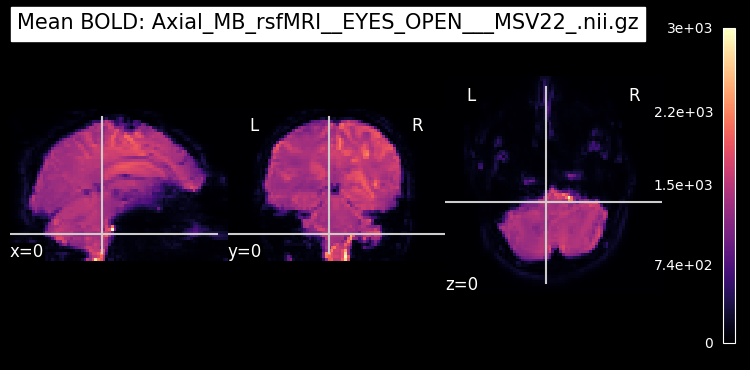

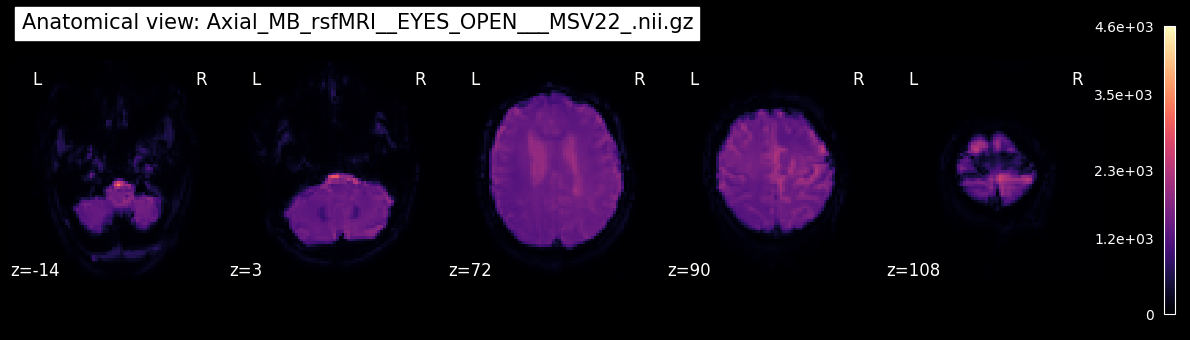

In [9]:
preprocessed_imgs = []

for nifti_path in nifti_files:
    if "rsfMRI" in nifti_path.name: 
        print(f"\n{nifti_path.name}:")
        
        img = nib.load(str(nifti_path))
   
        mean_img = image.mean_img(img)
        
        smooth_img = image.smooth_img(img, fwhm=6)
        mean_smooth_img = image.mean_img(smooth_img)
        
        mean_path = output_dir / (nifti_path.stem.split('.')[0] + "_mean.nii.gz")
        mean_img.to_filename(mean_path)
        
        print(f"BOLD map for {nifti_path.name}:")
        nlp.plot_epi(mean_img, title=f"Mean BOLD: {nifti_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma')
        plt.show()
        
        nlp.plot_anat(mean_img, title=f"Anatomical view: {nifti_path.name}", display_mode='z', cut_coords=5, cmap='magma')
        plt.show()
        
        preprocessed_imgs.append(mean_path)

In [11]:
import numpy as np
import nibabel as nib
import nilearn.plotting as nlp
from nilearn import image, masking
import matplotlib.pyplot as plt


2 ASL files: ['WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz', 'WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz']

ASL: WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz


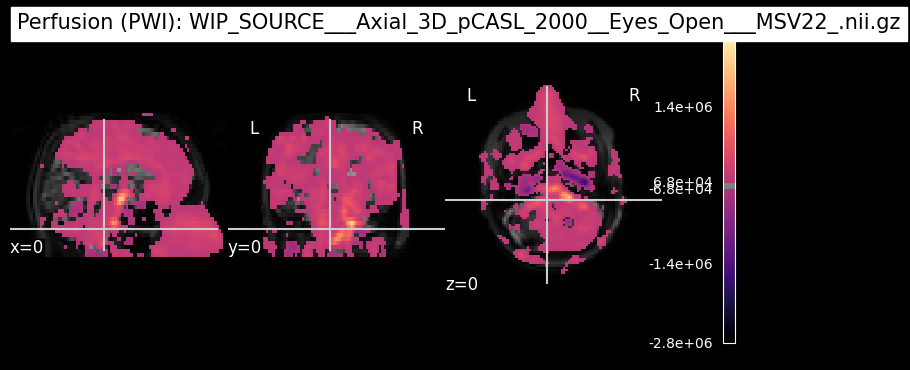

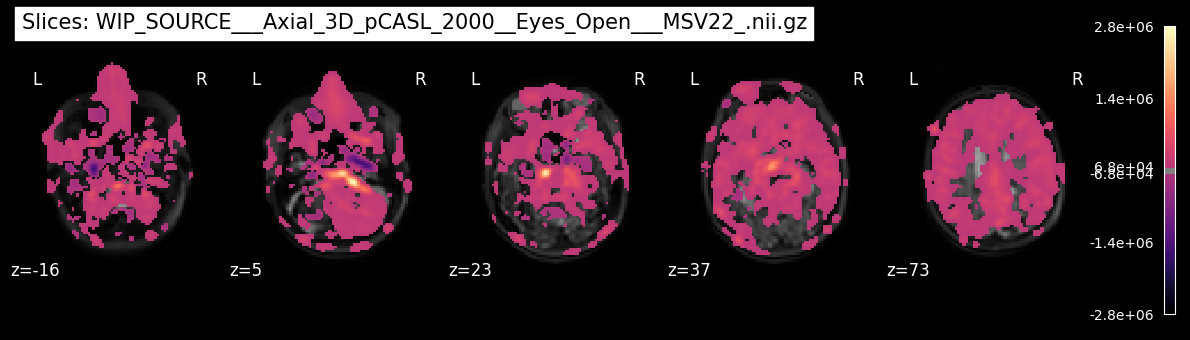


ASL: WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz


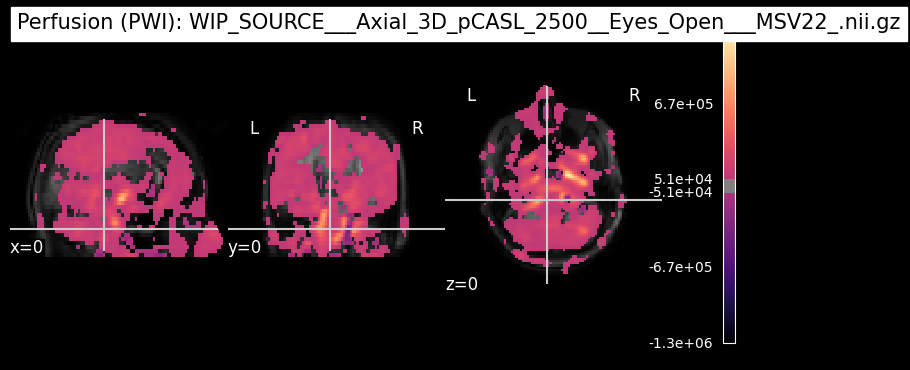

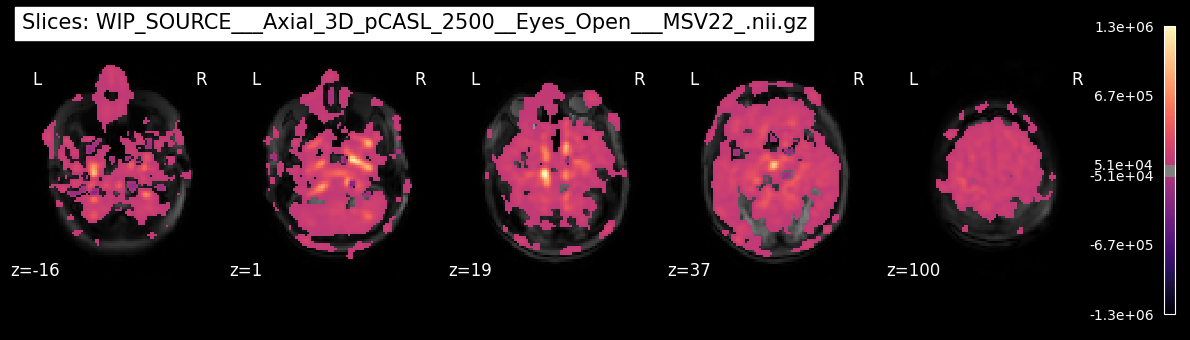

In [13]:
asl_files = [f for f in nifti_files if "pCASL" in f.name] 

print(f"{len(asl_files)} ASL files: {[f.name for f in asl_files]}")

for asl_path in asl_files: 
    print(f"\nASL: {asl_path.name}") 
    img = nib.load(str(asl_path)) 
    data = img.get_fdata()
    
    if data.ndim != 4:  #not 4D
        continue

    if data.shape[3] % 2 != 0:
        data = data[..., :-1]

    pwi_raw = np.mean(data[..., 0::2] - data[..., 1::2], axis=3)

    mask_img = masking.compute_epi_mask(image.mean_img(img))
    if np.mean(pwi_raw[mask_img.get_fdata().astype(bool)]) < 0:
        pwi_raw = -pwi_raw

    pwi_img = nib.Nifti1Image(pwi_raw, img.affine, img.header)
    pwi_smooth = image.smooth_img(pwi_img, fwhm=6)
    
    output_path = output_dir / (asl_path.stem.split('.')[0] + "_PWI_smooth.nii.gz")
    pwi_smooth.to_filename(output_path)

    mean_bg = image.mean_img(img)
    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Perfusion (PWI): {asl_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma', threshold='auto')
    plt.show()

    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Slices: {asl_path.name}", display_mode='z', cut_coords=5, cmap='magma', threshold='auto')
    plt.show()